In [ ]:
# ============================================================
# Task 3: Energy Consumption Time Series Forecasting
# ============================================================

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
import logging

logging.getLogger("cmdstanpy").disabled = True

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

In [ ]:
# ============================================================
# 1. Load Dataset
# ============================================================

In [12]:
df = pd.read_csv("household_power_consumption.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


First 5 Rows:
         Date      Time Global_active_power Global_reactive_power Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.84   
1  16/12/2006  17:25:00                5.36                 0.436  233.63   
2  16/12/2006  17:26:00               5.374                 0.498  233.29   
3  16/12/2006  17:27:00               5.388                 0.502  233.74   
4  16/12/2006  17:28:00               3.666                 0.528  235.68   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0             18.4              0              1            17.0  
1               23              0              1            16.0  
2               23              0              2            17.0  
3               23              0              1            17.0  
4             15.8              0              1            17.0  

Dataset Shape:
(1048575, 9)

Columns:
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Vo

In [ ]:
# ============================================================
# 2. Parse Date and Time
# ============================================================

In [13]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Datetime"])
df = df.set_index("Datetime")

In [ ]:
# ============================================================
# 3. Convert Target Column to Numeric
# ============================================================

In [14]:
df["Global_active_power"] = pd.to_numeric(
    df["Global_active_power"],
    errors="coerce"
)

df["Global_active_power"] = df["Global_active_power"].ffill()

In [ ]:
# ============================================================
# 4. Resample Data Daily
# ============================================================

In [15]:
daily_data = df["Global_active_power"].resample("D").mean()
daily_data = daily_data.dropna()

# Use recent 365 days for faster ARIMA and Prophet processing
daily_data = daily_data[-365:]

print("\nDaily Resampled Data:")
print(daily_data.head())

print("\nDaily Data Shape:")
print(daily_data.shape)


Daily Resampled Data:
Datetime
2007-12-15    1.900608
2007-12-16    1.918207
2007-12-17    1.248904
2007-12-18    1.821662
2007-12-19    1.525036
Freq: D, Name: Global_active_power, dtype: float64

Daily Data Shape:
(365,)


In [ ]:
# ============================================================
# 5. Exploratory Data Analysis
# ============================================================

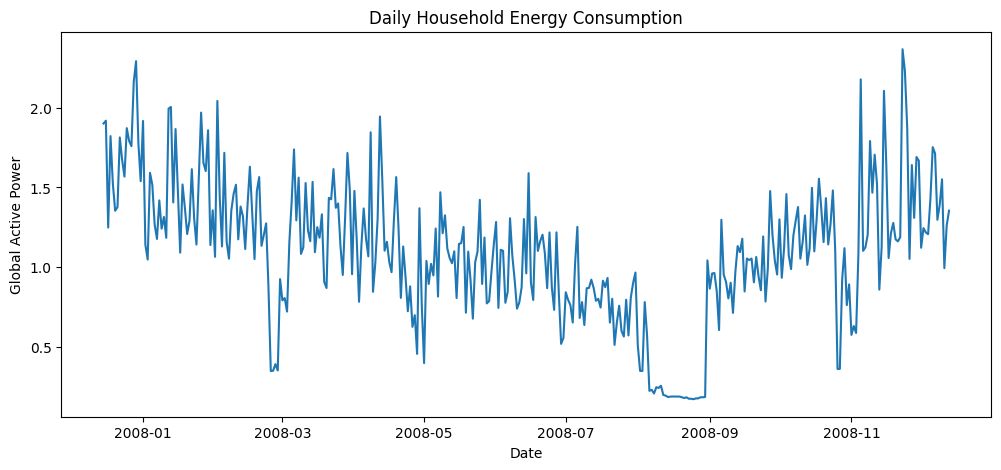

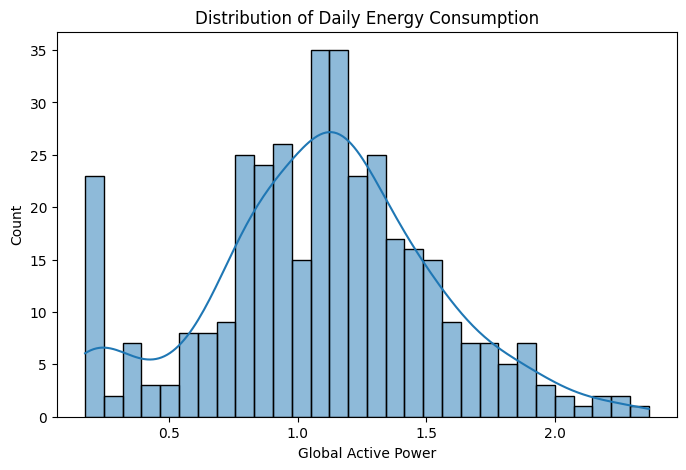

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(daily_data)
plt.title("Daily Household Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(daily_data, bins=30, kde=True)
plt.title("Distribution of Daily Energy Consumption")
plt.xlabel("Global Active Power")
plt.show()

In [ ]:
# ============================================================
# 6. Feature Engineering
# ============================================================

In [18]:
data = pd.DataFrame()
data["Global_active_power"] = daily_data

data["day"] = data.index.day
data["month"] = data.index.month
data["year"] = data.index.year
data["dayofweek"] = data.index.dayofweek
data["is_weekend"] = data["dayofweek"].apply(lambda x: 1 if x >= 5 else 0)

data["lag_1"] = data["Global_active_power"].shift(1)
data["lag_7"] = data["Global_active_power"].shift(7)
data["rolling_mean_7"] = data["Global_active_power"].rolling(window=7).mean()

data = data.dropna()

print("\nFeature Engineered Data:")
print(data.head())



Feature Engineered Data:
            Global_active_power  day  month  year  dayofweek  is_weekend  \
Datetime                                                                   
2007-12-22             1.813378   22     12  2007          5           1   
2007-12-23             1.672950   23     12  2007          6           1   
2007-12-24             1.567950   24     12  2007          0           0   
2007-12-25             1.871506   25     12  2007          1           0   
2007-12-26             1.791861   26     12  2007          2           0   

               lag_1     lag_7  rolling_mean_7  
Datetime                                        
2007-12-22  1.376789  1.900608        1.579711  
2007-12-23  1.813378  1.918207        1.544674  
2007-12-24  1.672950  1.248904        1.590252  
2007-12-25  1.567950  1.821662        1.597372  
2007-12-26  1.871506  1.525036        1.635490  


In [ ]:
# ============================================================
# 7. Train-Test Split
# ============================================================

In [20]:
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

print("\nTrain Size:", train.shape)
print("Test Size:", test.shape)


Train Size: (286, 9)
Test Size: (72, 9)


In [ ]:
# ============================================================
# 8. Evaluation Function
# ============================================================

In [21]:
def evaluate_model(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    print(f"\n{model_name} Performance")
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))

    return mae, rmse

In [ ]:
# ============================================================
# 9. ARIMA Model
# ============================================================


ARIMA Performance
MAE: 0.3224
RMSE: 0.4369


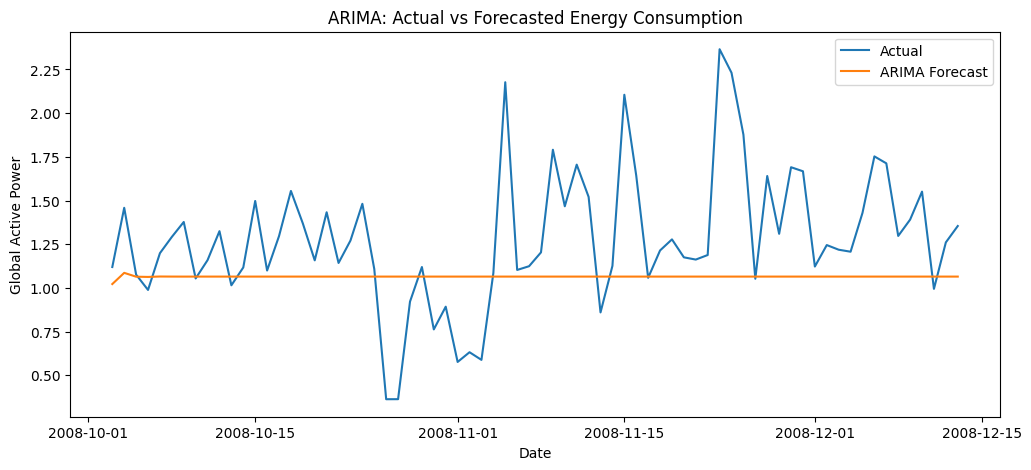

In [22]:
arima_model = ARIMA(
    train["Global_active_power"],
    order=(2, 1, 2)
)

arima_result = arima_model.fit()

arima_pred = arima_result.forecast(steps=len(test))

arima_mae, arima_rmse = evaluate_model(
    test["Global_active_power"],
    arima_pred,
    "ARIMA"
)

plt.figure(figsize=(12, 5))
plt.plot(test.index, test["Global_active_power"], label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA Forecast")
plt.title("ARIMA: Actual vs Forecasted Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# 10. Prophet Model
# ============================================================


Prophet Performance
MAE: 0.877
RMSE: 0.9587


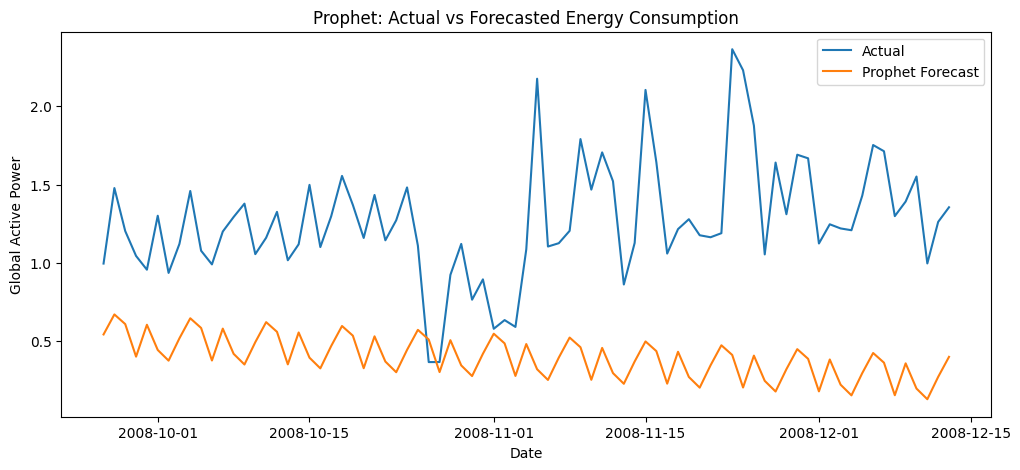

In [23]:
prophet_df = daily_data.reset_index()
prophet_df.columns = ["ds", "y"]

prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]

prophet_model = Prophet()
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq="D"
)

forecast = prophet_model.predict(future)

prophet_pred = forecast["yhat"].iloc[-len(prophet_test):].values

prophet_mae, prophet_rmse = evaluate_model(
    prophet_test["y"],
    prophet_pred,
    "Prophet"
)

plt.figure(figsize=(12, 5))
plt.plot(prophet_test["ds"], prophet_test["y"], label="Actual")
plt.plot(prophet_test["ds"], prophet_pred, label="Prophet Forecast")
plt.title("Prophet: Actual vs Forecasted Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

In [6]:
# ============================================================
# 11. XGBoost Model
# ============================================================


XGBoost Performance
MAE: 0.2362
RMSE: 0.3265


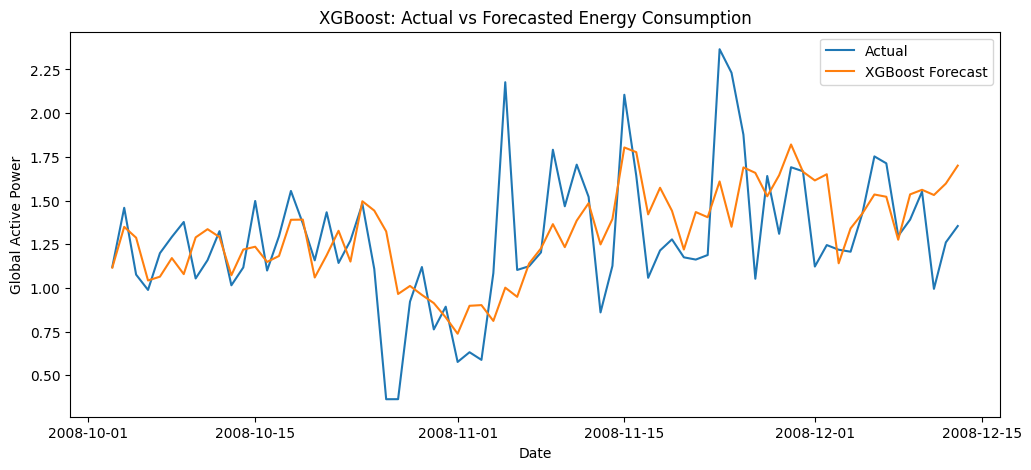

In [24]:
features = [
    "day",
    "month",
    "year",
    "dayofweek",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7"
]

X_train = train[features]
y_train = train["Global_active_power"]

X_test = test[features]
y_test = test["Global_active_power"]

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae, xgb_rmse = evaluate_model(
    y_test,
    xgb_pred,
    "XGBoost"
)

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, xgb_pred, label="XGBoost Forecast")
plt.title("XGBoost: Actual vs Forecasted Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# 12. Model Comparison
# ============================================================


Model Comparison:
     Model       MAE      RMSE
0    ARIMA  0.322448  0.436925
1  XGBoost  0.236209  0.326511
2  Prophet  0.876989  0.958710


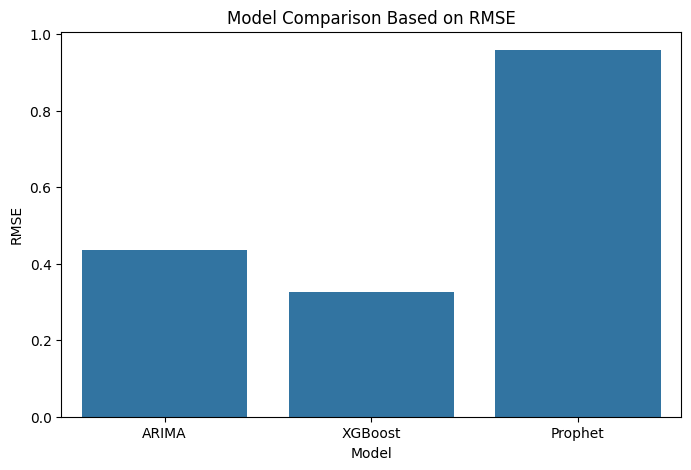

In [25]:
results = pd.DataFrame({
    "Model": ["ARIMA", "XGBoost", "Prophet"],
    "MAE": [arima_mae, xgb_mae, prophet_mae],
    "RMSE": [arima_rmse, xgb_rmse, prophet_rmse]
})

print("\nModel Comparison:")
print(results)

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="RMSE", data=results)
plt.title("Model Comparison Based on RMSE")
plt.ylabel("RMSE")
plt.show()

In [ ]:
# ============================================================
# Actual vs All Model Forecasts Comparison - Fixed
# ============================================================

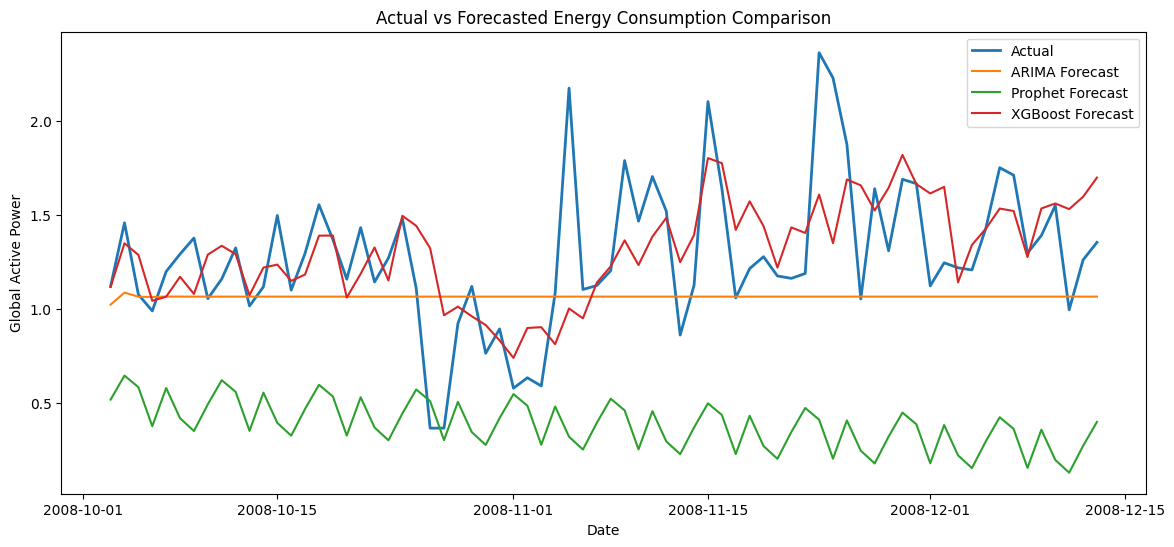

In [26]:
prophet_pred_fixed = prophet_pred[-len(test):]

plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test["Global_active_power"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test.index,
    arima_pred,
    label="ARIMA Forecast"
)

plt.plot(
    test.index,
    prophet_pred_fixed,
    label="Prophet Forecast"
)

plt.plot(
    test.index,
    xgb_pred,
    label="XGBoost Forecast"
)

plt.title("Actual vs Forecasted Energy Consumption Comparison")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# 13. Conclusion
# ============================================================

In [27]:
best_model = results.sort_values(by="RMSE").iloc[0]["Model"]

print("\n================ Conclusion ================")

print(f"The best performing model based on RMSE is: {best_model}")


================ Conclusion ================
The best performing model based on RMSE is: XGBoost


In [ ]:
# In this project, household energy consumption data was analyzed and used to forecast future energy usage through time series forecasting techniques. 
# After parsing and resampling the data, time-based features such as weekdays, weekends, lag values, and rolling averages were engineered to improve predictive performance.
# Three forecasting models—ARIMA, Prophet, and XGBoost—were evaluated using MAE and RMSE metrics. 
# Among them, XGBoost achieved the best performance with the lowest prediction error, demonstrating its ability to effectively capture temporal patterns in energy consumption data. 
# Overall, this project highlights the importance of feature engineering and model comparison in developing accurate forecasting solutions for real-world energy management applications.
